In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

(np.uint8(78), np.uint8(206))

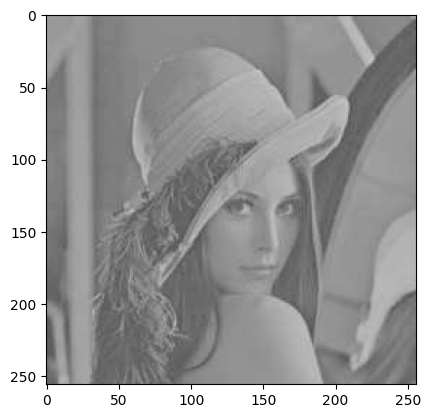

In [3]:
Image = np.ndarray

image: Image = cv.imread("./assets/image.png", cv.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)

image.min(), image.max()

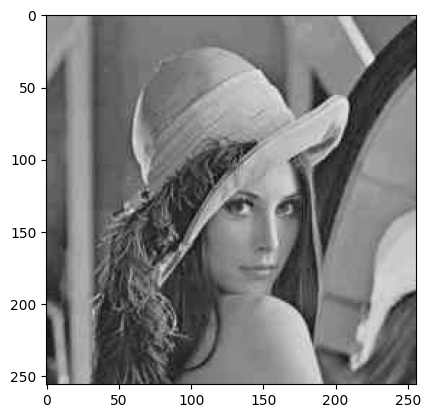

In [4]:
def high_contrast(img: Image) -> Image:
    return 255 * ((img - img.min()) / (img.max() - img.min()))

plt.imshow(high_contrast(image), cmap='gray', vmin=0, vmax=255)

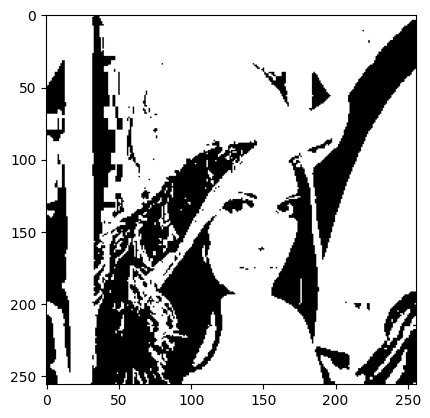

In [5]:
def binary(img: Image, t: int):
    return np.where(img > t, 255, 0)

plt.imshow(binary(high_contrast(image), 95), cmap='gray', vmin=0, vmax=255)

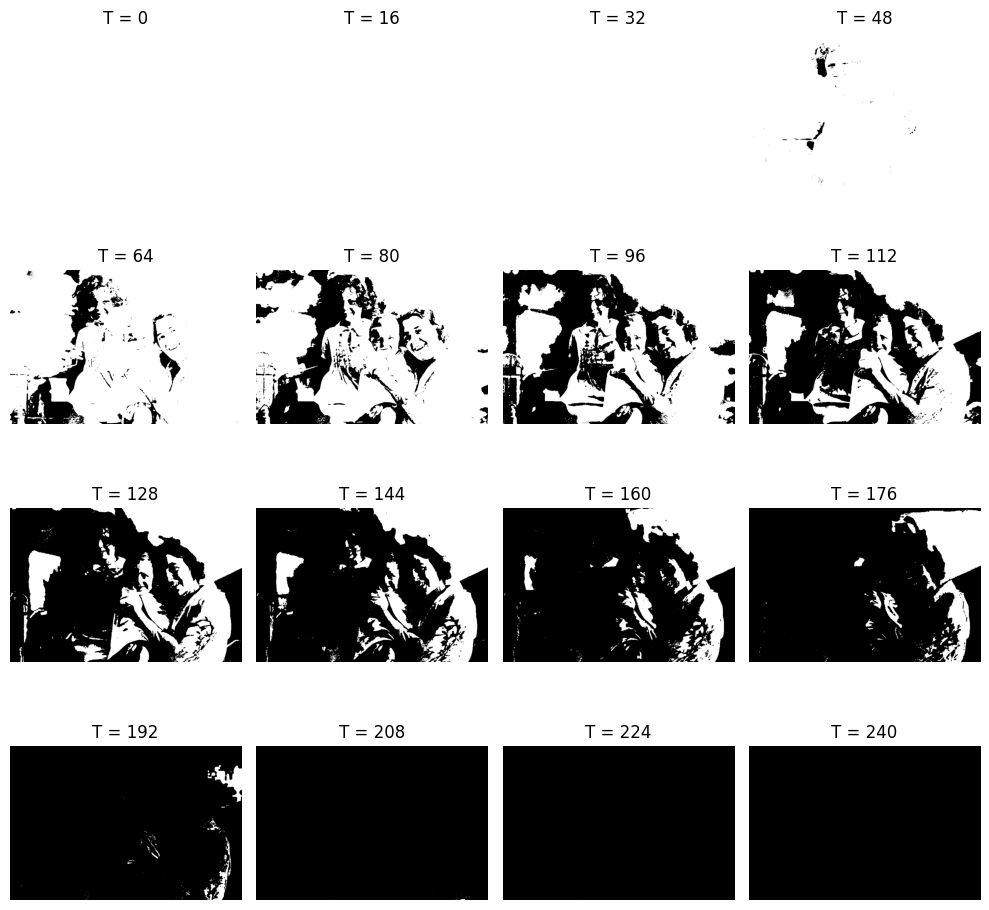

In [22]:
fig, axes = plt.subplots(4, 4, figsize=(10,10))

thresholds = range(0, 256, 16)

for ax, t in zip(axes.flat, thresholds):
    ax.imshow(binary(image, t), cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"T = {t}")
    ax.axis('off')

plt.tight_layout()
plt.show()

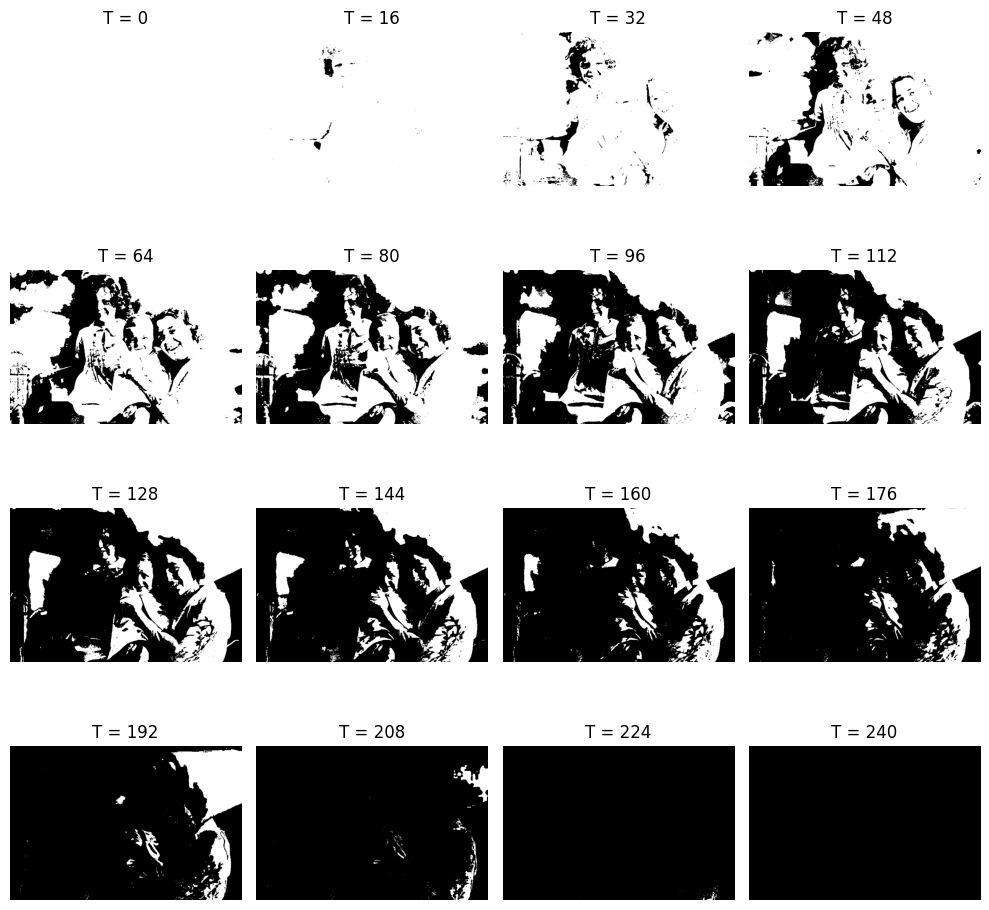

In [23]:
hc = high_contrast(image)

fig, axes = plt.subplots(4, 4, figsize=(10,10))

thresholds = range(0, 256, 16)

for ax, t in zip(axes.flat, thresholds):
    ax.imshow(binary(hc, t), cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"T = {t}")
    ax.axis('off')

plt.tight_layout()
plt.show()

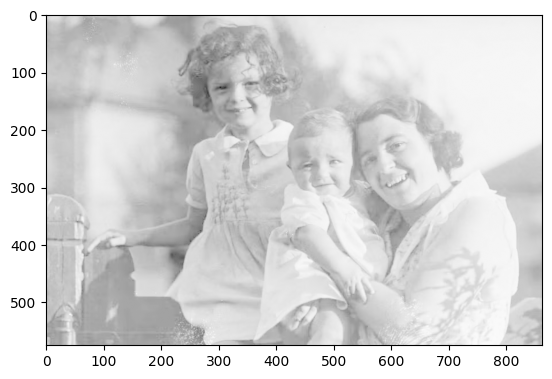

In [27]:
def log_compression(img: Image):
    return np.log10(1 + img) * (255 / np.log10(1 + img.max()))

plt.imshow(log_compression(high_contrast(image)), cmap='gray', vmin=0, vmax=255)